# Cybercrime Evolution (2015–2024) – Trend and Pattern Analysis

The goals of this notebook:

- Compute year-on-year growth rates for complaints and losses by crime type
- Calculate loss-per-complaint ratios to identify disproportionately
  costly categories
- Apply clustering to group crime types by their growth behaviour
- Identify anomalies and structural shifts in the time series

All analysis uses the harmonised long-format panel built in `2 - Advanced EDA with Plots`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

panel = pd.read_csv('data/processed/ic3_panel_long_harmonised.csv')


panel.columns = [c.strip() for c in panel.columns]
panel["Crime Type Harmonised"] = panel["Crime Type Harmonised"].astype(str).str.strip()
panel = panel.sort_values(["Crime Type Harmonised", "Year"]).reset_index(drop=True)

print(panel.shape)
panel.head(10)

(390, 4)


,Crime Type Harmonised,Year,Victim Count,Loss $
0,419/Overpayment,2015,30855.0,49217119.0
1,419/Overpayment,2016,25716.0,56004836.0
2,419/Overpayment,2017,23135.0,53450830.0
3,419/Overpayment,2018,15512.0,53225507.0
4,419/Overpayment,2019,15395.0,55820212.0
5,419/Overpayment,2020,10988.0,51039922.0
6,419/Overpayment,2021,6108.0,33407671.0
7,419/Overpayment,2022,6183.0,38335772.0
8,419/Overpayment,2023,4144.0,27955195.0
9,419/Overpayment,2024,2705.0,21452521.0


In [2]:
# Compute year-on-year % change per crime type
panel_sorted = panel.sort_values(["Crime Type Harmonised", "Year"])

panel_sorted["Complaints YoY (%)"] = (
    panel_sorted.groupby("Crime Type Harmonised")["Victim Count"]
    .pct_change() * 100
)

panel_sorted["Losses YoY (%)"] = (
    panel_sorted.groupby("Crime Type Harmonised")["Loss $"]
    .pct_change() * 100
)
panel_sorted['Complaints YoY (%)'] = panel_sorted['Complaints YoY (%)'].replace([np.inf, -np.inf], np.nan)
panel_sorted['Losses YoY (%)']     = panel_sorted['Losses YoY (%)'].replace([np.inf, -np.inf], np.nan)
panel_sorted.head(20)


,Crime Type Harmonised,Year,Victim Count,Loss $,Complaints YoY (%),Losses YoY (%)
0,419/Overpayment,2015,30855.0,49217119.0,NaN,NaN
1,419/Overpayment,2016,25716.0,56004836.0,-16.655323,13.791374
2,419/Overpayment,2017,23135.0,53450830.0,-10.036553,-4.560331
3,419/Overpayment,2018,15512.0,53225507.0,-32.950076,-0.421552
4,419/Overpayment,2019,15395.0,55820212.0,-0.754255,4.874928
5,419/Overpayment,2020,10988.0,51039922.0,-28.626177,-8.563726
6,419/Overpayment,2021,6108.0,33407671.0,-44.412086,-34.545999
7,419/Overpayment,2022,6183.0,38335772.0,1.227898,14.751405
8,419/Overpayment,2023,4144.0,27955195.0,-32.977519,-27.078043
9,419/Overpayment,2024,2705.0,21452521.0,-34.724903,-23.261058


In [3]:
# Average annual growth rate across all years per crime type
DISCONTINUED = ['Auction', 'Criminal Forums', 'No Lead Value']

avg_growth = (
    panel_sorted.groupby("Crime Type Harmonised")[
        ["Complaints YoY (%)", "Losses YoY (%)"]
    ]
    .mean()
    .round(1)
    .sort_values("Losses YoY (%)", ascending=False)
    .reset_index()
)

avg_growth

,Crime Type Harmonised,Complaints YoY (%),Losses YoY (%)
0,Government Impersonation,5.9,19283.4
1,Civil Matter,-13.6,438.2
2,Health Care Related,2.8,372.6
3,Charity,-6.1,111.6
4,Crimes Against Children,120.0,105.0
5,Phishing,46.5,101.9
6,Data Breach,-3.0,94.0
7,Tech Support,1.5,92.2
8,Investment,49.2,80.5
9,Terrorism,-38.8,76.7


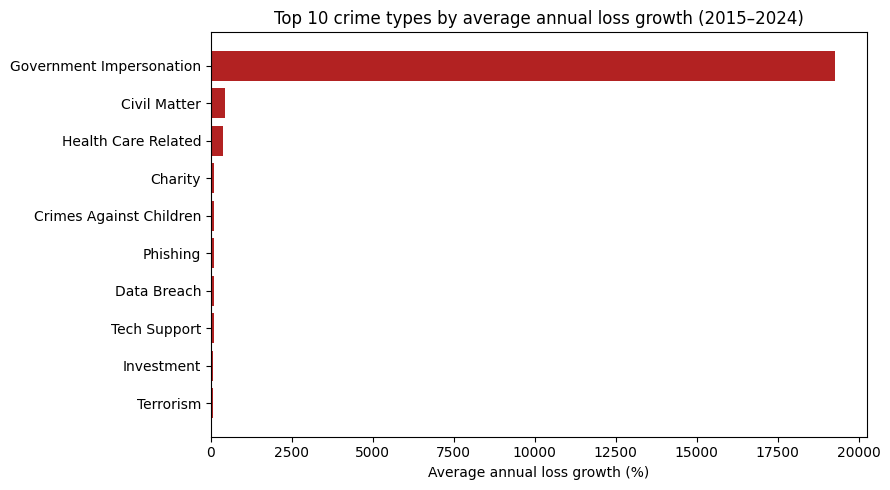

In [4]:
top_loss_growth = avg_growth.dropna(subset=["Losses YoY (%)"]).head(10)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(
    top_loss_growth["Crime Type Harmonised"][::-1],
    top_loss_growth["Losses YoY (%)"][::-1],
    color="firebrick"
)
ax.set_xlabel("Average annual loss growth (%)")
ax.set_title("Top 10 crime types by average annual loss growth (2015–2024)")
plt.tight_layout()
plt.savefig("fig_avg_loss_growth.png", dpi=150)
plt.show()


In [5]:
panel_sorted["Loss per Complaint $"] = (
    panel_sorted["Loss $"] / panel_sorted["Victim Count"]
).replace([np.inf, -np.inf], np.nan)

# Latest year snapshot (2024)
lpc_2024 = (
    panel_sorted[panel_sorted["Year"] == 2024]
    [["Crime Type Harmonised", "Loss per Complaint $"]]
    .dropna()
    .sort_values("Loss per Complaint $", ascending=False)
    .reset_index(drop=True)
)

lpc_2024["Loss per Complaint $"] = lpc_2024["Loss per Complaint $"].round(0)
lpc_2024


,Crime Type Harmonised,Loss per Complaint $
0,Investment,137120.0
1,BEC/EAC,129193.0
2,Data Breach,113875.0
3,Tech Support,40685.0
4,Confidence/Romance Fraud,37521.0
5,Lottery/Sweepstakes/Inheritance,27700.0
6,SIM Swap,26460.0
7,Government Impersonation,23356.0
8,Other,22754.0
9,Personal Data Breach,22399.0


In [33]:
# Regression: Complaints vs Loss

reg_df = panel_sorted.copy()
reg_df['Log Complaints'] = np.log1p(reg_df['Victim Count'])
reg_df['Log Loss'] = np.log1p(reg_df['Loss $'])

reg_df = reg_df.dropna(subset=['Log Complaints', 'Log Loss'])

from sklearn.linear_model import LinearRegression

X = reg_df[['Log Complaints']]
y = reg_df['Log Loss']

model = LinearRegression()
model.fit(X, y)

print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)
print("R^2:", model.score(X, y))

Coefficient: 1.7483943327079932
Intercept: 1.3516543306806348
R^2: 0.8284173586644706


### Regression Insight: Drivers of Financial Loss

A log-log linear regression model was used to examine the relationship between complaint volume and financial loss.

The regression results show a strong positive relationship (R² ≈ 0.83), indicating that a large proportion of variation in losses is explained by complaint volume.

Because a log-log model is used, the coefficient can be interpreted as an elasticity. A 1% increase in complaints is associated with approximately a 1.74% increase in financial losses.

This suggests that losses increase more than proportionally with complaints, implying that cybercrime growth is not purely driven by volume, but also by increasing financial severity per incident.

Overall, this provides evidence that cybercrime is evolving towards fewer but more financially impactful attacks.

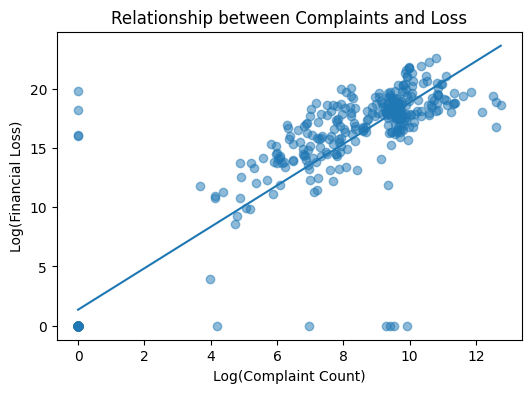

In [32]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,4))

# Scatter plot
plt.scatter(reg_df['Log Complaints'], reg_df['Log Loss'], alpha=0.5)

# Regression line
x_vals = np.linspace(reg_df['Log Complaints'].min(), reg_df['Log Complaints'].max(), 100)
y_vals = model.intercept_ + model.coef_[0] * x_vals
plt.plot(x_vals, y_vals)

# Labels
plt.xlabel("Log(Complaint Count)")
plt.ylabel("Log(Financial Loss)")
plt.title("Relationship between Complaints and Loss")

plt.show()

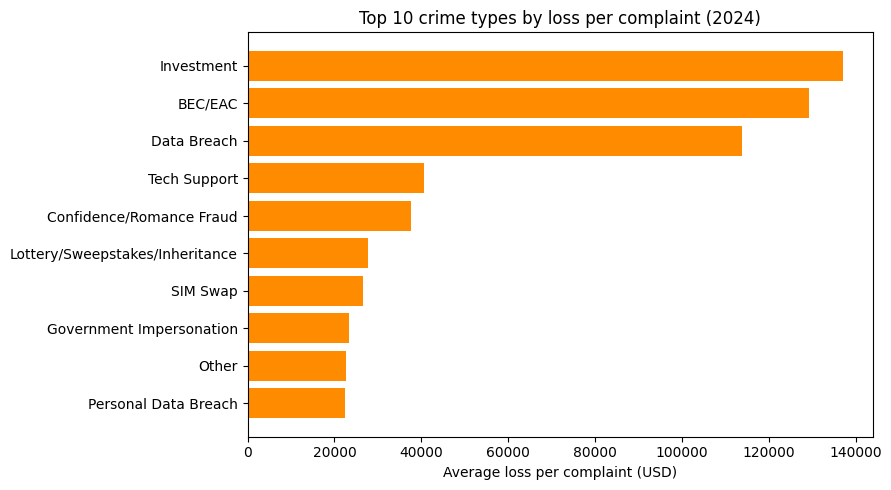

In [25]:
top_lpc = lpc_2024.head(10)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(
    top_lpc["Crime Type Harmonised"][::-1],
    top_lpc["Loss per Complaint $"][::-1],
    color="darkorange"
)
ax.set_xlabel("Average loss per complaint (USD)")
ax.set_title("Top 10 crime types by loss per complaint (2024)")
plt.tight_layout()
plt.savefig("fig_loss_per_complaint_2024.png", dpi=150)
plt.show()


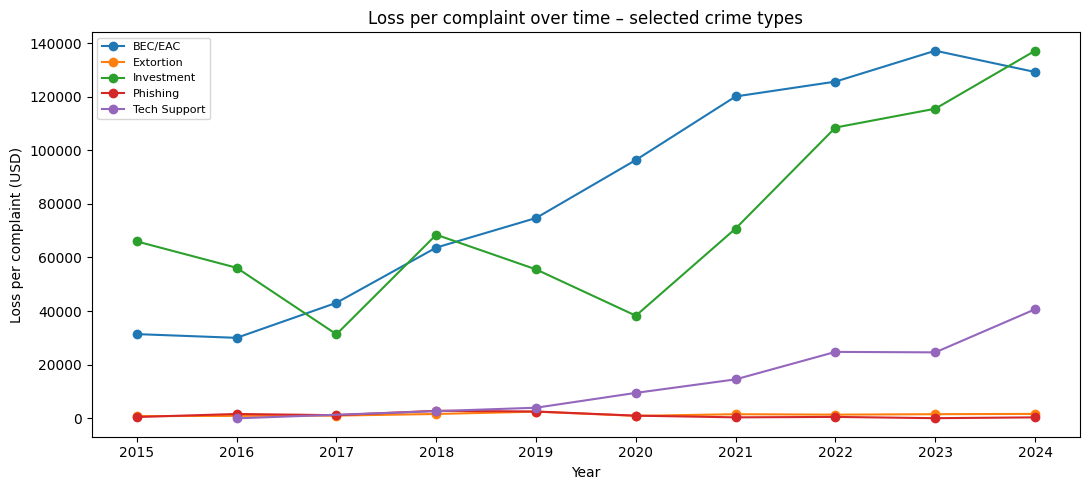

In [7]:
key_crimes = ["BEC/EAC", "Investment", "Phishing", "Extortion", "Tech Support"]

lpc_trend = panel_sorted[
    panel_sorted["Crime Type Harmonised"].isin(key_crimes)
][["Crime Type Harmonised", "Year", "Loss per Complaint $"]].dropna()

fig, ax = plt.subplots(figsize=(11, 5))
for crime, group in lpc_trend.groupby("Crime Type Harmonised"):
    g = group.sort_values("Year")
    ax.plot(g["Year"], g["Loss per Complaint $"], marker="o", label=crime)

ax.set_title("Loss per complaint over time – selected crime types")
ax.set_xlabel("Year")
ax.set_ylabel("Loss per complaint (USD)")
ax.legend(fontsize=8)
ax.set_xticks(range(2015, 2025))
plt.tight_layout()
plt.savefig("fig_lpc_trend.png", dpi=150)
plt.show()


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer

# Pivot complaints to wide format: rows = crime types, cols = years
complaints_wide = panel_sorted.pivot_table(
    index='Crime Type Harmonised', columns='Year', values='Victim Count'
)
losses_wide = panel_sorted.pivot_table(
    index='Crime Type Harmonised', columns='Year', values='Loss $'
)

idx = complaints_wide.index    

X_raw = np.hstack([complaints_wide.values, losses_wide.values])

# Impute missing with column mean (only for clustering)
imputer = SimpleImputer(strategy="mean")
X = imputer.fit_transform(complaints_wide)

# Normalise so large-volume crimes don't dominate
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature matrix shape:", X_scaled.shape)


Feature matrix shape: (39, 10)


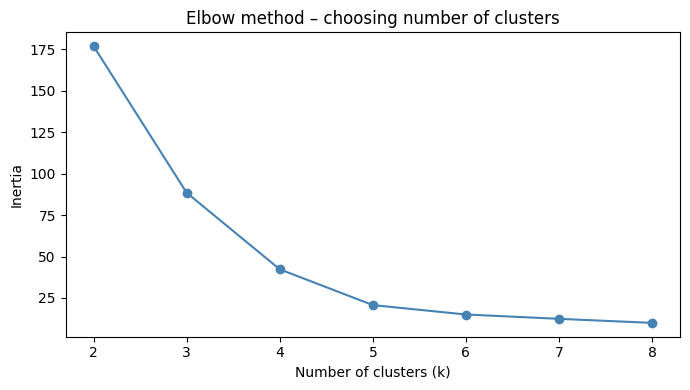

In [9]:
inertias = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(k_range), inertias, marker="o", color="steelblue")
ax.set_title("Elbow method – choosing number of clusters")
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Inertia")
plt.tight_layout()
plt.savefig("fig_elbow.png", dpi=150)
plt.show()


In [10]:
K = 3
km = KMeans(n_clusters=K, random_state=42, n_init=10)
labels = km.fit_predict(X)

cluster_result = pd.DataFrame({
    'Crime Type Harmonised': idx,
    'Cluster': labels
}).sort_values('Cluster').reset_index(drop=True)

for c in sorted(cluster_result['Cluster'].unique()):
    crimes = cluster_result[cluster_result['Cluster'] == c]['Crime Type Harmonised'].tolist()
    print(f"Cluster {c} ({len(crimes)} types):")
    for ct in crimes:
        print(f"  {ct}")

print(f"Cluster 0: {len(cluster_result[cluster_result['Cluster']==0])} crime types share broadly similar moderate growth trajectories.")


Cluster 0 (35 types):
  419/Overpayment
  Advanced Fee
  Auction
  BEC/EAC
  Botnet
  Charity
  Civil Matter
  Confidence/Romance Fraud
  Credit Card/Check Fraud
  Crimes Against Children
  Criminal Forums
  Data Breach
  Denial of Service
  Denial of Service/TDoS
  Employment
  Gambling
  Lottery/Sweepstakes/Inheritance
  Government Impersonation
  Hacktivist
  Harassment/Threats
  Health Care Related
  IPR/Copyright/Counterfeit
  Identity Theft
  Investment
  Other
  Malware/Scareware/Virus
  Misrepresentation
  No Lead Value
  SIM Swap
  Real Estate
  Re-shipping
  Ransomware
  Tech Support
  Terrorism
  Virus
Cluster 1 (1 types):
  Phishing
Cluster 2 (3 types):
  Personal Data Breach
  Non-Payment/Non-Delivery
  Extortion
Cluster 0: 35 crime types share broadly similar moderate growth trajectories.


# Interpretation Note
Cluster 1: Phishing is isolated as a volume outlier.
Cluster 2: Personal Data Breach, Extortion, Non-Payment show sustained mid-volume growth.
This result reflects genuine data concentration, not a modelling failure.

In [11]:
# Show which crime types fall in each cluster
for c in sorted(cluster_result["Cluster"].unique()):
    crimes = cluster_result[cluster_result["Cluster"] == c]["Crime Type Harmonised"].tolist()
    print(f"\nCluster {c} ({len(crimes)} crime types):")
    for crime in crimes:
        print(f"  - {crime}")



Cluster 0 (35 crime types):
  - 419/Overpayment
  - Advanced Fee
  - Auction
  - BEC/EAC
  - Botnet
  - Charity
  - Civil Matter
  - Confidence/Romance Fraud
  - Credit Card/Check Fraud
  - Crimes Against Children
  - Criminal Forums
  - Data Breach
  - Denial of Service
  - Denial of Service/TDoS
  - Employment
  - Gambling
  - Lottery/Sweepstakes/Inheritance
  - Government Impersonation
  - Hacktivist
  - Harassment/Threats
  - Health Care Related
  - IPR/Copyright/Counterfeit
  - Identity Theft
  - Investment
  - Other
  - Malware/Scareware/Virus
  - Misrepresentation
  - No Lead Value
  - SIM Swap
  - Real Estate
  - Re-shipping
  - Ransomware
  - Tech Support
  - Terrorism
  - Virus

Cluster 1 (1 crime types):
  - Phishing

Cluster 2 (3 crime types):
  - Personal Data Breach
  - Non-Payment/Non-Delivery
  - Extortion


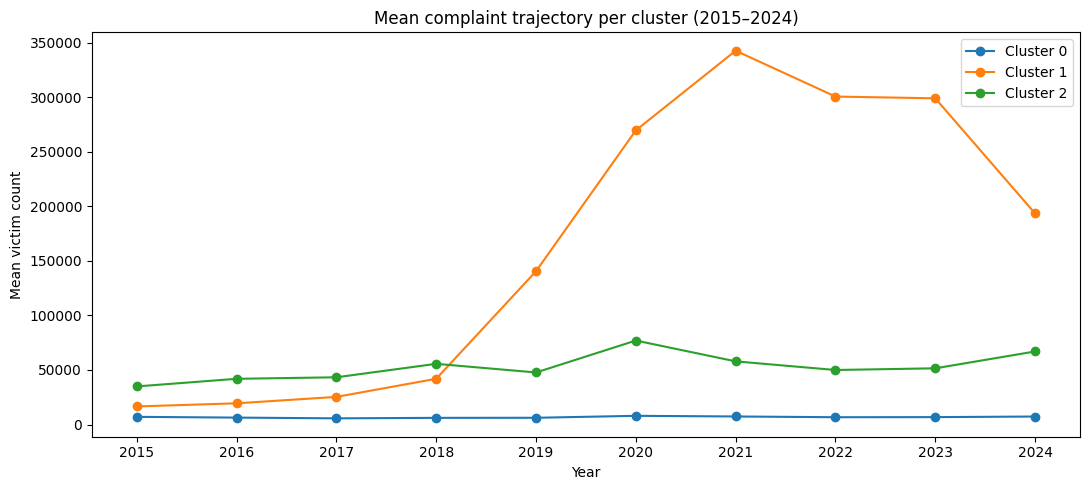

In [12]:
# Mean complaint trajectory per cluster
fig, ax = plt.subplots(figsize=(11, 5))

years = [c for c in complaints_wide.columns if isinstance(c, int)]

for c in sorted(cluster_result["Cluster"].unique()):
    crimes_in_cluster = cluster_result[cluster_result["Cluster"] == c]["Crime Type Harmonised"]
    mean_trajectory = complaints_wide.loc[
        complaints_wide.index.isin(crimes_in_cluster), years
    ].mean()
    ax.plot(years, mean_trajectory, marker="o", label=f"Cluster {c}")

ax.set_title("Mean complaint trajectory per cluster (2015–2024)")
ax.set_xlabel("Year")
ax.set_ylabel("Mean victim count")
ax.legend()
ax.set_xticks(years)
plt.tight_layout()
plt.savefig("fig_cluster_trajectories.png", dpi=150)
plt.show()


In [13]:
yearly_totals = (
    panel_sorted.groupby("Year")[["Victim Count", "Loss $"]]
    .sum()
    .reset_index()
)

for col in ["Victim Count", "Loss $"]:
    mean = yearly_totals[col].mean()
    std  = yearly_totals[col].std()
    yearly_totals[f"{col} Z-Score"] = ((yearly_totals[col] - mean) / std).round(2)

yearly_totals["Complaint Anomaly"] = yearly_totals["Victim Count Z-Score"].abs() > 1.5
yearly_totals["Loss Anomaly"]      = yearly_totals["Loss $ Z-Score"].abs() > 1.5

yearly_totals

,Year,Victim Count,Loss $,Victim Count Z-Score,Loss $ Z-Score,Complaint Anomaly,Loss Anomaly
0,2015,368762.0,1.240162e+09,-1.10,-1.01,False,False
1,2016,368194.0,1.443696e+09,-1.10,-0.97,False,False
2,2017,354567.0,1.720592e+09,-1.18,-0.91,False,False
3,2018,423743.0,3.415816e+09,-0.78,-0.58,False,False
4,2019,501119.0,4.384107e+09,-0.34,-0.40,False,False
5,2020,780403.0,5.046417e+09,1.26,-0.27,False,False
6,2021,775222.0,7.647476e+09,1.23,0.24,False,False
7,2022,685738.0,1.093060e+10,0.72,0.87,False,False
8,2023,691701.0,1.234724e+10,0.75,1.15,False,False
9,2024,651865.0,1.608841e+10,0.53,1.87,False,True


In [14]:
panel_sorted.to_csv("ic3_panel_with_growth.csv", index=False)
avg_growth.to_csv("ic3_avg_growth_by_crime.csv", index=False)
lpc_2024.to_csv("ic3_loss_per_complaint_2024.csv", index=False)
cluster_result.to_csv("ic3_crime_clusters.csv", index=False)
yearly_totals.to_csv("ic3_yearly_totals_with_anomalies.csv", index=False)